In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from arch import arch_model
from statsmodels.stats.diagnostic import het_arch
from scipy.stats import skew, kurtosis
import statsmodels.api as sm
from scipy.stats import t

In [2]:
# 读取上证数据
data_000001 = pd.read_excel('./Data/000001_data.xls',usecols=[0,2,3])
data_000001.columns = ['stock_code','date','close']
data_000001

,stock_code,date,close
0,1,2000-01-04,1406.3710
1,1,2000-01-05,1409.6820
2,1,2000-01-06,1463.9420
3,1,2000-01-07,1516.6040
4,1,2000-01-10,1545.1120
...,...,...,...
5084,1,2020-12-25,3396.5626
5085,1,2020-12-28,3397.2854
5086,1,2020-12-29,3379.0362
5087,1,2020-12-30,3414.4527


In [3]:
# 读取深圳成指 
data_339001 = pd.read_excel('./Data/339001_data.xls',usecols=[0,2,3])
data_339001.columns = ['stock_code','date','close']
data_339001

,stock_code,date,close
0,399001,2003-09-08,3157.373
1,399001,2003-09-09,3136.614
2,399001,2003-09-10,3148.666
3,399001,2003-09-11,3160.817
4,399001,2003-09-12,3135.531
...,...,...,...
5084,399001,2003-09-01,3249.193
5085,399001,2003-09-02,3238.856
5086,399001,2003-09-03,3233.794
5087,399001,2003-09-04,3226.909


In [4]:
# 读取600600股票数据
data_600600_2000 = pd.read_excel('./Data/2000/600600.xls')
data_600600_2010 = pd.read_excel('./Data/2001-2010/600600.xls')
data_600600_2015 = pd.read_excel('./Data/2011-2015/600600.xls')
data_600600_2020 = pd.read_excel('./Data/2016-2020/600600.xls')
data_600600 = pd.concat([data_600600_2000,data_600600_2010],axis=0,ignore_index=True)
data_600600 = pd.concat([data_600600,data_600600_2015],axis=0,ignore_index=True)
data_600600 = pd.concat([data_600600,data_600600_2020],axis=0,ignore_index=True)
data_600600.columns = ['stock_code','date','close']
data_600600

,stock_code,date,close
0,600600,2000-01-04,8.29
1,600600,2000-01-05,8.33
2,600600,2000-01-06,8.74
3,600600,2000-01-07,9.10
4,600600,2000-01-10,9.25
...,...,...,...
5113,600600,2020-12-25,98.00
5114,600600,2020-12-28,98.10
5115,600600,2020-12-29,99.12
5116,600600,2020-12-30,99.66


In [5]:
# 读取000600股票数据
data_000600_2000 = pd.read_excel('./Data/2000/000600.xls')

data_000600_2010 = pd.read_excel('./Data/2001-2010/000600.xls')
data_000600_2015 = pd.read_excel('./Data/2011-2015/000600.xls')
data_000600_2020 = pd.read_excel('./Data/2016-2020/000600.xls')
data_000600 = pd.concat([data_000600_2000,data_000600_2010],axis=0,ignore_index=True)
data_000600 = pd.concat([data_000600,data_000600_2015],axis=0,ignore_index=True)
data_000600 = pd.concat([data_000600,data_000600_2020],axis=0,ignore_index=True)
data_000600.columns = ['stock_code','date','close']
data_000600

,stock_code,date,close
0,600,2000-02-17,10.53
1,600,2000-02-18,11.58
2,600,2000-02-21,12.74
3,600,2000-02-22,14.01
4,600,2000-02-23,12.61
...,...,...,...
5135,600,2020-12-25,5.89
5136,600,2020-12-28,5.94
5137,600,2020-12-29,5.71
5138,600,2020-12-30,5.68


In [6]:
# 计算上证指数的收益率
data_000001['return'] = np.log(data_000001['close']) - np.log(data_000001['close']).shift(periods=1)
data_000001.dropna(inplace=True)
# 计算各个股票收益率
data_339001['return'] = np.log(data_339001['close']) - np.log(data_339001['close']).shift(periods=1)
data_339001.dropna(inplace=True)
data_000600['return'] = np.log(data_000600['close']) - np.log(data_000600['close']).shift(periods=1)
data_000600.dropna(inplace=True)
data_600600['return'] = np.log(data_600600['close']) - np.log(data_600600['close']).shift(periods=1)
data_600600.dropna(inplace=True)
data_000001

,stock_code,date,close,return
1,1,2000-01-05,1409.6820,0.002352
2,1,2000-01-06,1463.9420,0.037769
3,1,2000-01-07,1516.6040,0.035341
4,1,2000-01-10,1545.1120,0.018623
5,1,2000-01-11,1479.7810,-0.043202
...,...,...,...,...
5084,1,2020-12-25,3396.5626,0.009897
5085,1,2020-12-28,3397.2854,0.000213
5086,1,2020-12-29,3379.0362,-0.005386
5087,1,2020-12-30,3414.4527,0.010427


In [7]:
# 自相关系数显著性检验
# 计算t统计量
# 这里使用n-1作为自由度，其中n是时间序列的长度
def t_test(xishu,n):
    t_stat = xishu / (1 / np.sqrt(n - 1))
    p_value = 2 * (1 - t.cdf(np.abs(t_stat), df=n-2))
    return p_value

In [8]:
# 收益率描述性统计
def stat_cal(stock_data):
    stock_data = stock_data[(stock_data['return'] >= -0.12) & (stock_data['return'] <= 0.12)]
    temp_data = stock_data.copy()
    trade_days = len(temp_data)
    mean = temp_data['return'].mean()
    std = temp_data['return'].std()
    skewness = skew(temp_data['return'])
    kurt = kurtosis(temp_data['return'])
    max_value = temp_data['return'].max()
    min_value = temp_data['return'].min()
    # 计算自相关系数，这里以1阶自相关为例
    autocorr1 = temp_data['return'].autocorr(lag=1)
    autocorr2 = temp_data['return'].autocorr(lag=2)
    autocorr3 = temp_data['return'].autocorr(lag=3)
    autocorr4 = temp_data['return'].autocorr(lag=4)
    autocorr5 = temp_data['return'].autocorr(lag=5)
    autocorr10 = temp_data['return'].autocorr(lag=10)
    autocorr15 = temp_data['return'].autocorr(lag=15)
    autocorr20 = temp_data['return'].autocorr(lag=20)
    t1 = t_test(autocorr1,trade_days)
    t2 = t_test(autocorr2,trade_days)
    t3 = t_test(autocorr3,trade_days)
    t4 = t_test(autocorr4,trade_days)
    t5 = t_test(autocorr5,trade_days)
    t10 = t_test(autocorr10,trade_days)
    t15 = t_test(autocorr15,trade_days)
    t20 = t_test(autocorr20,trade_days)
    print(f"交易日天数: {trade_days}")
    print(f"均值: {mean}")
    print(f"标准差: {std}")
    print(f"偏度: {skewness}")
    print(f"峰度: {kurt}")
    print(f"最大值: {max_value}")
    print(f"最小值: {min_value}")
    print(f"1阶自相关系数: {autocorr1}")
    print(f"1阶p值: {t1}")
    print(f"2阶自相关系数: {autocorr2}")
    print(f"2阶p值: {t2}")
    print(f"3阶自相关系数: {autocorr3}")
    print(f"3阶p值: {t3}")
    print(f"4阶自相关系数: {autocorr4}")
    print(f"4阶p值: {t4}")
    print(f"5阶自相关系数: {autocorr5}")
    print(f"5阶p值: {t5}")
    print(f"10阶自相关系数: {autocorr10}")
    print(f"10阶p值: {t10}")
    print(f"15阶自相关系数: {autocorr15}")
    print(f"15阶p值: {t15}")
    print(f"20阶自相关系数: {autocorr20}")
    print(f"20阶p值: {t20}")

In [9]:
# 收益率绝对值描述性统计
def stat_cal_abs(stock_data):
    stock_data = stock_data[(stock_data['return'] >= -0.12) & (stock_data['return'] <= 0.12)]
    temp_data = stock_data.copy()
    temp_data['return'] = abs(temp_data['return'])
    trade_days = len(temp_data)
    mean = temp_data['return'].mean()
    std = temp_data['return'].std()
    skewness = skew(temp_data['return'])
    kurt = kurtosis(temp_data['return'])
    max_value = temp_data['return'].max()
    min_value = temp_data['return'].min()
    # 计算自相关系数，这里以1阶自相关为例
    autocorr1 = temp_data['return'].autocorr(lag=1)
    autocorr2 = temp_data['return'].autocorr(lag=2)
    autocorr3 = temp_data['return'].autocorr(lag=3)
    autocorr4 = temp_data['return'].autocorr(lag=4)
    autocorr5 = temp_data['return'].autocorr(lag=5)
    autocorr10 = temp_data['return'].autocorr(lag=10)
    autocorr15 = temp_data['return'].autocorr(lag=15)
    autocorr20 = temp_data['return'].autocorr(lag=20)
    t1 = t_test(autocorr1,trade_days)
    t2 = t_test(autocorr2,trade_days)
    t3 = t_test(autocorr3,trade_days)
    t4 = t_test(autocorr4,trade_days)
    t5 = t_test(autocorr5,trade_days)
    t10 = t_test(autocorr10,trade_days)
    t15 = t_test(autocorr15,trade_days)
    t20 = t_test(autocorr20,trade_days)
    print(f"交易日天数: {trade_days}")
    print(f"均值: {mean}")
    print(f"标准差: {std}")
    print(f"偏度: {skewness}")
    print(f"峰度: {kurt}")
    print(f"最大值: {max_value}")
    print(f"最小值: {min_value}")
    print(f"1阶自相关系数: {autocorr1}")
    print(f"1阶p值: {t1}")
    print(f"2阶自相关系数: {autocorr2}")
    print(f"2阶p值: {t2}")
    print(f"3阶自相关系数: {autocorr3}")
    print(f"3阶p值: {t3}")
    print(f"4阶自相关系数: {autocorr4}")
    print(f"4阶p值: {t4}")
    print(f"5阶自相关系数: {autocorr5}")
    print(f"5阶p值: {t5}")
    print(f"10阶自相关系数: {autocorr10}")
    print(f"10阶p值: {t10}")
    print(f"15阶自相关系数: {autocorr15}")
    print(f"15阶p值: {t15}")
    print(f"20阶自相关系数: {autocorr20}")
    print(f"20阶p值: {t20}")

In [10]:
stat_cal(data_000001)

交易日天数: 5088
均值: 0.00017767808564853627
标准差: 0.015485412853441495
偏度: -0.3707036016626765
峰度: 5.0087580258300015
最大值: 0.09400972715464029
最小值: -0.09256085382231127
1阶自相关系数: 0.02214019814001947
1阶p值: 0.11437302513557657
2阶自相关系数: -0.01982992908216794
2阶p值: 0.15732502475292898
3阶自相关系数: 0.02868993527982502
3阶p值: 0.0407822830206257
4阶自相关系数: 0.04392675830570508
4阶p值: 0.0017401450092129345
5阶自相关系数: -0.0028640722830518706
5阶p值: 0.838146916698302
10阶自相关系数: 0.00019185405157166391
10阶p值: 0.9890829071933853
15阶自相关系数: 0.03555398386410005
15阶p值: 0.011247987598928422
20阶自相关系数: 0.0215881306298145
20阶p值: 0.12368723667285098


In [11]:
stat_cal_abs(data_000001)

交易日天数: 5088
均值: 0.010557876609008641
标准差: 0.011328676709301787
偏度: 2.5220964374921837
峰度: 9.533612052260812
最大值: 0.09400972715464029
最小值: 1.222867624051105e-06
1阶自相关系数: 0.17883838922246278
1阶p值: 0.0
2阶自相关系数: 0.21376442818075841
2阶p值: 0.0
3阶自相关系数: 0.21925539566754843
3阶p值: 0.0
4阶自相关系数: 0.20835661569054348
4阶p值: 0.0
5阶自相关系数: 0.18113672835456976
5阶p值: 0.0
10阶自相关系数: 0.21857909063217054
10阶p值: 0.0
15阶自相关系数: 0.15174956860767078
15阶p值: 0.0
20阶自相关系数: 0.19031343610815543
20阶p值: 0.0


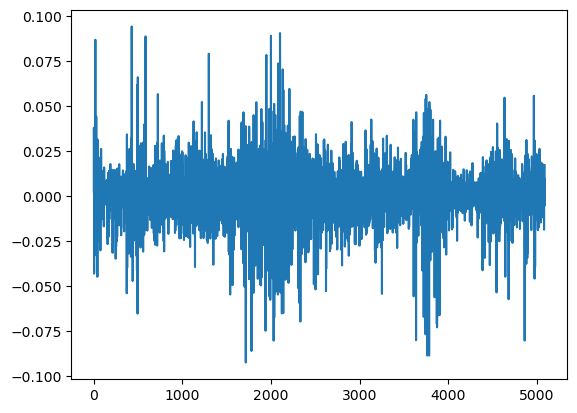

In [12]:
# 上证指数的收益率时间序列图
plt.plot(data_000001['return'])